# 12 — Validación por bloques mensuales sobre toda la serie (forward-chaining)

**RESPIR-AI · TFG** — Las 36 ventanas del protocolo v2 se concentran en julio–noviembre de 2025.
Este cuaderno amplía la evaluación a **toda la serie** con validación por bloques mensuales en
*forward chaining*: para cada mes natural k que deja al menos 6 meses de historia previa,
TEST = mes k y TRAIN = todo lo anterior a k (ventana expansiva; el último 12,5 % de las horas
útiles previas hace de validación para el early stopping de TTM). Sin fugas: cada modelo solo ve
datos anteriores al inicio del bloque; los orígenes del bloque cumplen el criterio del protocolo
(≥512 h de contexto y 48 h de futuro dentro del mismo segmento, paso 24 h).

Modelos (mejores configuraciones fijas, sin re-tunear por bloque):
- **XGBoost recursivo E1 y E3** (48 retardos, hiperparámetros del cuaderno 03), re-entrenado por bloque.
- **Chronos-2 ZS U (C=512) y F (C=256)** — sin entrenamiento.
- **TTM ZS U** (sin entrenamiento) y **TTM ft5 F** (few-shot 5 % re-entrenado por bloque).

Esto responde dos preguntas: ¿aparecen diferencias significativas con más ventanas? y
¿cambia el ranking entre estaciones (invierno/primavera vs verano)?

In [1]:
# Raíz del repositorio como cwd
import os, sys
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd()/"common_eval.py").exists() else Path.cwd().parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

import time, warnings
import numpy as np, pandas as pd, torch
from xgboost import XGBRegressor
from skforecast.recursive import ForecasterRecursiveMultiSeries
from chronos import Chronos2Pipeline
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction
from scipy import stats
warnings.filterwarnings("ignore")
from common_eval import *
import common_eval as CE

df, proto = load_all()
seg = df.segment_id.to_numpy()
y_masked = df['our'].where(df.segment_id >= 0)
first_useful = df.index[seg >= 0][0]

# bloques mensuales con >= 6 meses de historia útil previa
meses = sorted(df.index.to_period('M').unique())
bloques = [m for m in meses if (m.start_time.tz_localize('UTC') - first_useful) >= pd.Timedelta(days=180)]

def origins_bloque(m):
    """Orígenes válidos dentro del mes m (criterio del protocolo, paso 24 h)."""
    in_month = (df.index.to_period('M') == m)
    out, last = [], -10**9
    for i in np.where(in_month)[0]:
        s = seg[i]
        if s < 0 or i - last < 24: continue
        if i-511 < 0 or (seg[i-511:i+1] != s).any(): continue
        if i+48 >= len(df) or (seg[i+1:i+49] != s).any(): continue
        out.append(i); last = i
    return out

plan = {m: origins_bloque(m) for m in bloques}
plan = {m: o for m, o in plan.items() if len(o) > 0}
n_tot = sum(len(o) for o in plan.values())
print(f"bloques con ventanas: {len(plan)} | ventanas totales: {n_tot}")
print({str(m): len(o) for m, o in plan.items()})

bloques con ventanas: 14 | ventanas totales: 188
{'2024-06': 4, '2024-07': 28, '2024-08': 31, '2024-09': 9, '2024-10': 5, '2024-11': 5, '2024-12': 14, '2025-03': 6, '2025-04': 23, '2025-07': 30, '2025-08': 6, '2025-09': 23, '2025-10': 2, '2025-11': 2}


## 1. Bucle forward-chaining

Por cada bloque: se re-entrena XGBoost (E1/E3) y el few-shot de TTM con los datos anteriores al
bloque; Chronos-2 y TTM zero-shot no necesitan entrenamiento. Las predicciones son las mismas
48 h por origen recortadas a cada H.

In [2]:
pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")
torch.manual_seed(42); np.random.seed(42)
DEV = "cuda"
CHANNELS = ['our'] + PROC + METEO
Xall = df[CHANNELS].to_numpy(dtype=np.float32)
meteo_idx = [CHANNELS.index(c) for c in METEO]
cols_F = [0] + meteo_idx
ex_idx = [cols_F.index(ci) for ci in meteo_idx]
HP03 = dict(learning_rate=0.05, max_depth=4, n_estimators=300)
y_asf = y_masked.asfreq('h'); meteo_asf = df[METEO].astype(float).asfreq('h')
WIN = 512 + 96

ttm_zs = TinyTimeMixerForPrediction.from_pretrained("ibm-granite/granite-timeseries-ttm-r2").to(DEV).eval()

def c2_predict(ilocs, C, with_f):
    dicts = []
    for i in ilocs:
        d = {"target": y_masked.iloc[i-C+1:i+1].to_numpy(dtype=np.float32)}
        if with_f:
            d["past_covariates"] = {c: df[c].iloc[i-C+1:i+1].to_numpy(dtype=np.float32) for c in METEO}
            d["future_covariates"] = {c: df[c].iloc[i+1:i+49].to_numpy(dtype=np.float32) for c in METEO}
        dicts.append(d)
    qs, means = pipe.predict_quantiles(dicts, prediction_length=48)
    return np.stack([m_.squeeze().numpy() for m_ in means]).astype(float)

def ttm_predict(model, ilocs, cols, use_fut):
    pasts, futs = [], []
    for i in ilocs:
        past = Xall[i-511:i+1][:, cols]
        fut = np.zeros((96, len(cols)), dtype=np.float32)
        n = min(96, len(df) - (i+1))
        if use_fut:
            for k_, ci in enumerate(cols):
                if ci in meteo_idx: fut[:n, k_] = Xall[i+1:i+1+n, ci]
        pasts.append(past); futs.append(fut)
    with torch.no_grad():
        out = model(past_values=torch.tensor(np.stack(pasts)).to(DEV),
                    future_values=torch.tensor(np.stack(futs)).to(DEV) if use_fut else None,
                    return_loss=False)
    return out.prediction_outputs[..., 0].float().cpu().numpy()[:, :48]

def window_starts_before(cut_iloc):
    """Inicios de ventana 512+96 íntegramente anteriores a cut_iloc, intra-segmento."""
    starts = []
    for s_id in np.unique(seg[seg >= 0]):
        idx = np.where(seg == s_id)[0]
        i0, i1 = idx[0], min(idx[-1], cut_iloc - 1)
        if i1 - i0 + 1 >= WIN:
            starts.extend(range(i0, i1 - WIN + 2))
    return np.array(starts)

def make_tensors(starts, cols):
    past = np.stack([Xall[s:s+512][:, cols] for s in starts])
    fut  = np.stack([Xall[s+512:s+608][:, cols] for s in starts])
    return torch.tensor(past), torch.tensor(fut)

def ttm_ft5_bloque(cut_iloc):
    starts = window_starts_before(cut_iloc)
    n_va = max(2, int(0.125 * len(starts)))
    starts = np.sort(starts)
    tr_pool, va_starts = starts[:-n_va], starts[-n_va:][::4] if n_va >= 4 else starts[-n_va:]
    rng = np.random.default_rng(42)
    tr5 = rng.choice(tr_pool, size=max(8, int(0.05*len(tr_pool))), replace=False)
    m = TinyTimeMixerForPrediction.from_pretrained(
        "ibm-granite/granite-timeseries-ttm-r2", num_input_channels=len(cols_F),
        decoder_mode="mix_channel", prediction_channel_indices=[0],
        exogenous_channel_indices=ex_idx, enable_forecast_channel_mixing=True,
        fcm_context_length=5, fcm_use_mixer=True, fcm_prepend_past=True,
        ignore_mismatched_sizes=True).to(DEV)
    torch.manual_seed(42); np.random.seed(42)
    Xtr, Ytr = make_tensors(tr5, cols_F); Xva, Yva = make_tensors(va_starts, cols_F)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-4)
    best, best_state, bad = np.inf, None, 0
    for ep in range(50):
        m.train()
        perm = torch.randperm(Xtr.shape[0])
        for k in range(0, Xtr.shape[0], 64):
            idx = perm[k:k+64]
            out = m(past_values=Xtr[idx].to(DEV), future_values=Ytr[idx].to(DEV), return_loss=True)
            opt.zero_grad(); out.loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            vl = float(m(past_values=Xva.to(DEV), future_values=Yva.to(DEV), return_loss=True).loss)
        if vl < best - 1e-5: best, bad, best_state = vl, 0, {k: v.detach().clone() for k, v in m.state_dict().items()}
        else:
            bad += 1
            if bad >= 5: break
    m.load_state_dict(best_state); m.eval()
    return m

CONFIGS = ["xgb_E1", "xgb_E3", "c2_zs_U_C512", "c2_zs_F_C256", "ttm_zs_U", "ttm_ft5_F"]
res_rows, win_rows = [], []
t_ini = time.perf_counter()
for m_per, ilocs in plan.items():
    cut = np.where(df.index >= m_per.start_time.tz_localize('UTC'))[0][0]
    Yb = np.stack([df['our'].iloc[i+1:i+49].to_numpy() for i in ilocs])
    cut_ts = df.index[cut]
    preds = {}
    # XGBoost re-entrenado con todo lo anterior al bloque
    for use_exog, tag in [(False, "xgb_E1"), (True, "xgb_E3")]:
        f = ForecasterRecursiveMultiSeries(
            estimator=XGBRegressor(**HP03, random_state=42, n_jobs=8, objective="reg:squarederror"),
            lags=48, encoding=None, dropna_from_series=True)
        f.fit(series=pd.DataFrame({"our": y_asf.loc[:cut_ts][:-1]}),
              exog=meteo_asf.loc[:cut_ts][:-1] if use_exog else None)
        P = []
        for i in ilocs:
            lw = pd.DataFrame({"our": df['our'].iloc[i-47:i+1]}).asfreq('h')
            ex = meteo_asf.iloc[i+1:i+49] if use_exog else None
            P.append(f.predict(steps=48, last_window=lw, exog=ex, levels="our")['pred'].to_numpy())
        preds[tag] = np.stack(P)
    # fundacionales
    preds["c2_zs_U_C512"] = c2_predict(ilocs, 512, False)
    preds["c2_zs_F_C256"] = c2_predict(ilocs, 256, True)
    preds["ttm_zs_U"] = ttm_predict(ttm_zs, ilocs, [0], False)
    mft = ttm_ft5_bloque(cut)
    preds["ttm_ft5_F"] = ttm_predict(mft, ilocs, cols_F, True)
    del mft; torch.cuda.empty_cache()
    for cfg, P in preds.items():
        for H in HORIZONS:
            e = Yb[:, :H] - P[:, :H]
            res_rows.append({"modelo": cfg.split("_")[0], "config": cfg, "bloque_mes": str(m_per),
                             "H": H, "n_ventanas": len(ilocs),
                             "MAE": float(np.abs(e).mean()), "RMSE": float(np.sqrt((e**2).mean())),
                             "R2": float(1 - (e**2).sum()/((Yb[:, :H]-Yb[:, :H].mean())**2).sum())})
            for w, i in enumerate(ilocs):
                win_rows.append({"config": cfg, "bloque_mes": str(m_per), "origen": str(df.index[i]),
                                 "H": H, "MAE": float(np.abs(Yb[w, :H]-P[w, :H]).mean())})
    print(f"{m_per}: {len(ilocs)} ventanas ({time.perf_counter()-t_ini:.0f} s)")
del pipe, ttm_zs; torch.cuda.empty_cache()

2024-06: 4 ventanas (4 s)
2024-07: 28 ventanas (8 s)
2024-08: 31 ventanas (11 s)
2024-09: 9 ventanas (17 s)
2024-10: 5 ventanas (21 s)
2024-11: 5 ventanas (27 s)
2024-12: 14 ventanas (31 s)
2025-03: 6 ventanas (37 s)
2025-04: 23 ventanas (44 s)
2025-07: 30 ventanas (49 s)
2025-08: 6 ventanas (56 s)
2025-09: 23 ventanas (66 s)
2025-10: 2 ventanas (72 s)
2025-11: 2 ventanas (76 s)


Loading weights: 100%|##########| 134/134 [00:00<00:00, 3161.76it/s]


## 2. Resultados agregados, Diebold-Mariano y Friedman sobre todas las ventanas

In [3]:
res_b = pd.DataFrame(res_rows)
res_b.to_csv("results/validacion_bloques.csv", index=False)
win_b = pd.DataFrame(win_rows)
win_b.to_parquet("results/errores_por_ventana_bloques.parquet", index=False)

# agregada por config (todas las ventanas juntas)
agg = win_b.groupby(["config", "H"]).MAE.mean().unstack().round(3)
print("MAE agregado (todas las ventanas):")
print(agg.to_string())

def dm_hln(d, h=1):
    n = len(d); dbar = d.mean()
    V = np.mean((d-dbar)**2)
    for k in range(1, h):
        V += 2*np.mean((d[k:]-dbar)*(d[:-k]-dbar))
    stat = (dbar/np.sqrt(V/n)) * np.sqrt((n + 1 - 2*h + h*(h-1)/n)/n)
    return stat, 2*stats.t.sf(abs(stat), df=n-1)

PARES = [("xgb_E3", "c2_zs_F_C256"), ("xgb_E3", "ttm_ft5_F"), ("c2_zs_F_C256", "ttm_ft5_F"),
         ("xgb_E1", "c2_zs_U_C512"), ("xgb_E1", "ttm_zs_U"), ("c2_zs_U_C512", "ttm_zs_U"),
         ("xgb_E1", "xgb_E3"), ("c2_zs_F_C256", "c2_zs_U_C512"), ("ttm_ft5_F", "ttm_zs_U")]
dm_rows = []
for a_cfg, b_cfg in PARES:
    for H in HORIZONS:
        a = win_b[(win_b.config==a_cfg) & (win_b.H==H)].sort_values("origen").MAE.to_numpy()
        b = win_b[(win_b.config==b_cfg) & (win_b.H==H)].sort_values("origen").MAE.to_numpy()
        s, p = dm_hln(a - b, h=max(1, int(np.ceil(H/24))))
        dm_rows.append({"config_a": a_cfg, "config_b": b_cfg, "H": H, "n": len(a),
                        "MAE_a": round(a.mean(), 3), "MAE_b": round(b.mean(), 3),
                        "DM_stat": round(s, 3), "p_valor": round(p, 4)})
df_dm_b = pd.DataFrame(dm_rows)
df_dm_b.to_csv("results/dm_bloques.csv", index=False)
print("\nDM significativos al 5%:")
print(df_dm_b[df_dm_b.p_valor < 0.05].to_string(index=False))

# Friedman por horizonte sobre la matriz ventanas x configs
fr_rows = []
for H in HORIZONS:
    piv = win_b[win_b.H==H].pivot(index="origen", columns="config", values="MAE")[CONFIGS].dropna()
    stat, p = stats.friedmanchisquare(*[piv[c] for c in CONFIGS])
    fr_rows.append({"H": H, "n_ventanas": len(piv), "chi2": round(stat, 2), "p_valor": round(p, 5),
                    "ranking_medio": " < ".join(piv.rank(axis=1).mean().sort_values().index)})
df_fr = pd.DataFrame(fr_rows)
df_fr.to_csv("results/friedman_bloques.csv", index=False)
print("\nFriedman:")
print(df_fr.to_string(index=False))

MAE agregado (todas las ventanas):
H                6      12     24     48
config                                  
c2_zs_F_C256  3.627  3.846  4.225  4.698
c2_zs_U_C512  3.664  3.885  4.303  4.877
ttm_ft5_F     4.143  4.302  4.772  5.285
ttm_zs_U      3.627  3.910  4.339  4.860
xgb_E1        3.688  4.068  4.518  5.071
xgb_E3        3.830  4.262  4.712  5.244

DM significativos al 5%:
    config_a     config_b  H   n  MAE_a  MAE_b  DM_stat  p_valor
      xgb_E3 c2_zs_F_C256 12 188  4.262  3.846    2.641   0.0090
      xgb_E3 c2_zs_F_C256 24 188  4.712  4.225    2.830   0.0052
      xgb_E3 c2_zs_F_C256 48 188  5.244  4.698    2.157   0.0323
c2_zs_F_C256    ttm_ft5_F  6 188  3.627  4.143   -3.568   0.0005
c2_zs_F_C256    ttm_ft5_F 12 188  3.846  4.302   -4.125   0.0001
c2_zs_F_C256    ttm_ft5_F 24 188  4.225  4.772   -4.715   0.0000
c2_zs_F_C256    ttm_ft5_F 48 188  4.698  5.285   -3.549   0.0005
      xgb_E1       xgb_E3  6 188  3.688  3.830   -2.392   0.0178
      xgb_E1       xgb_E3 

## 3. Análisis estacional

MAE por mes de test y familia. La salvedad importante: en los bloques tempranos XGBoost y el
few-shot de TTM entrenan con menos datos (ventana expansiva), mientras que los zero-shot no
dependen del tamaño de la historia — la comparación por mes mezcla estación y tamaño de train.

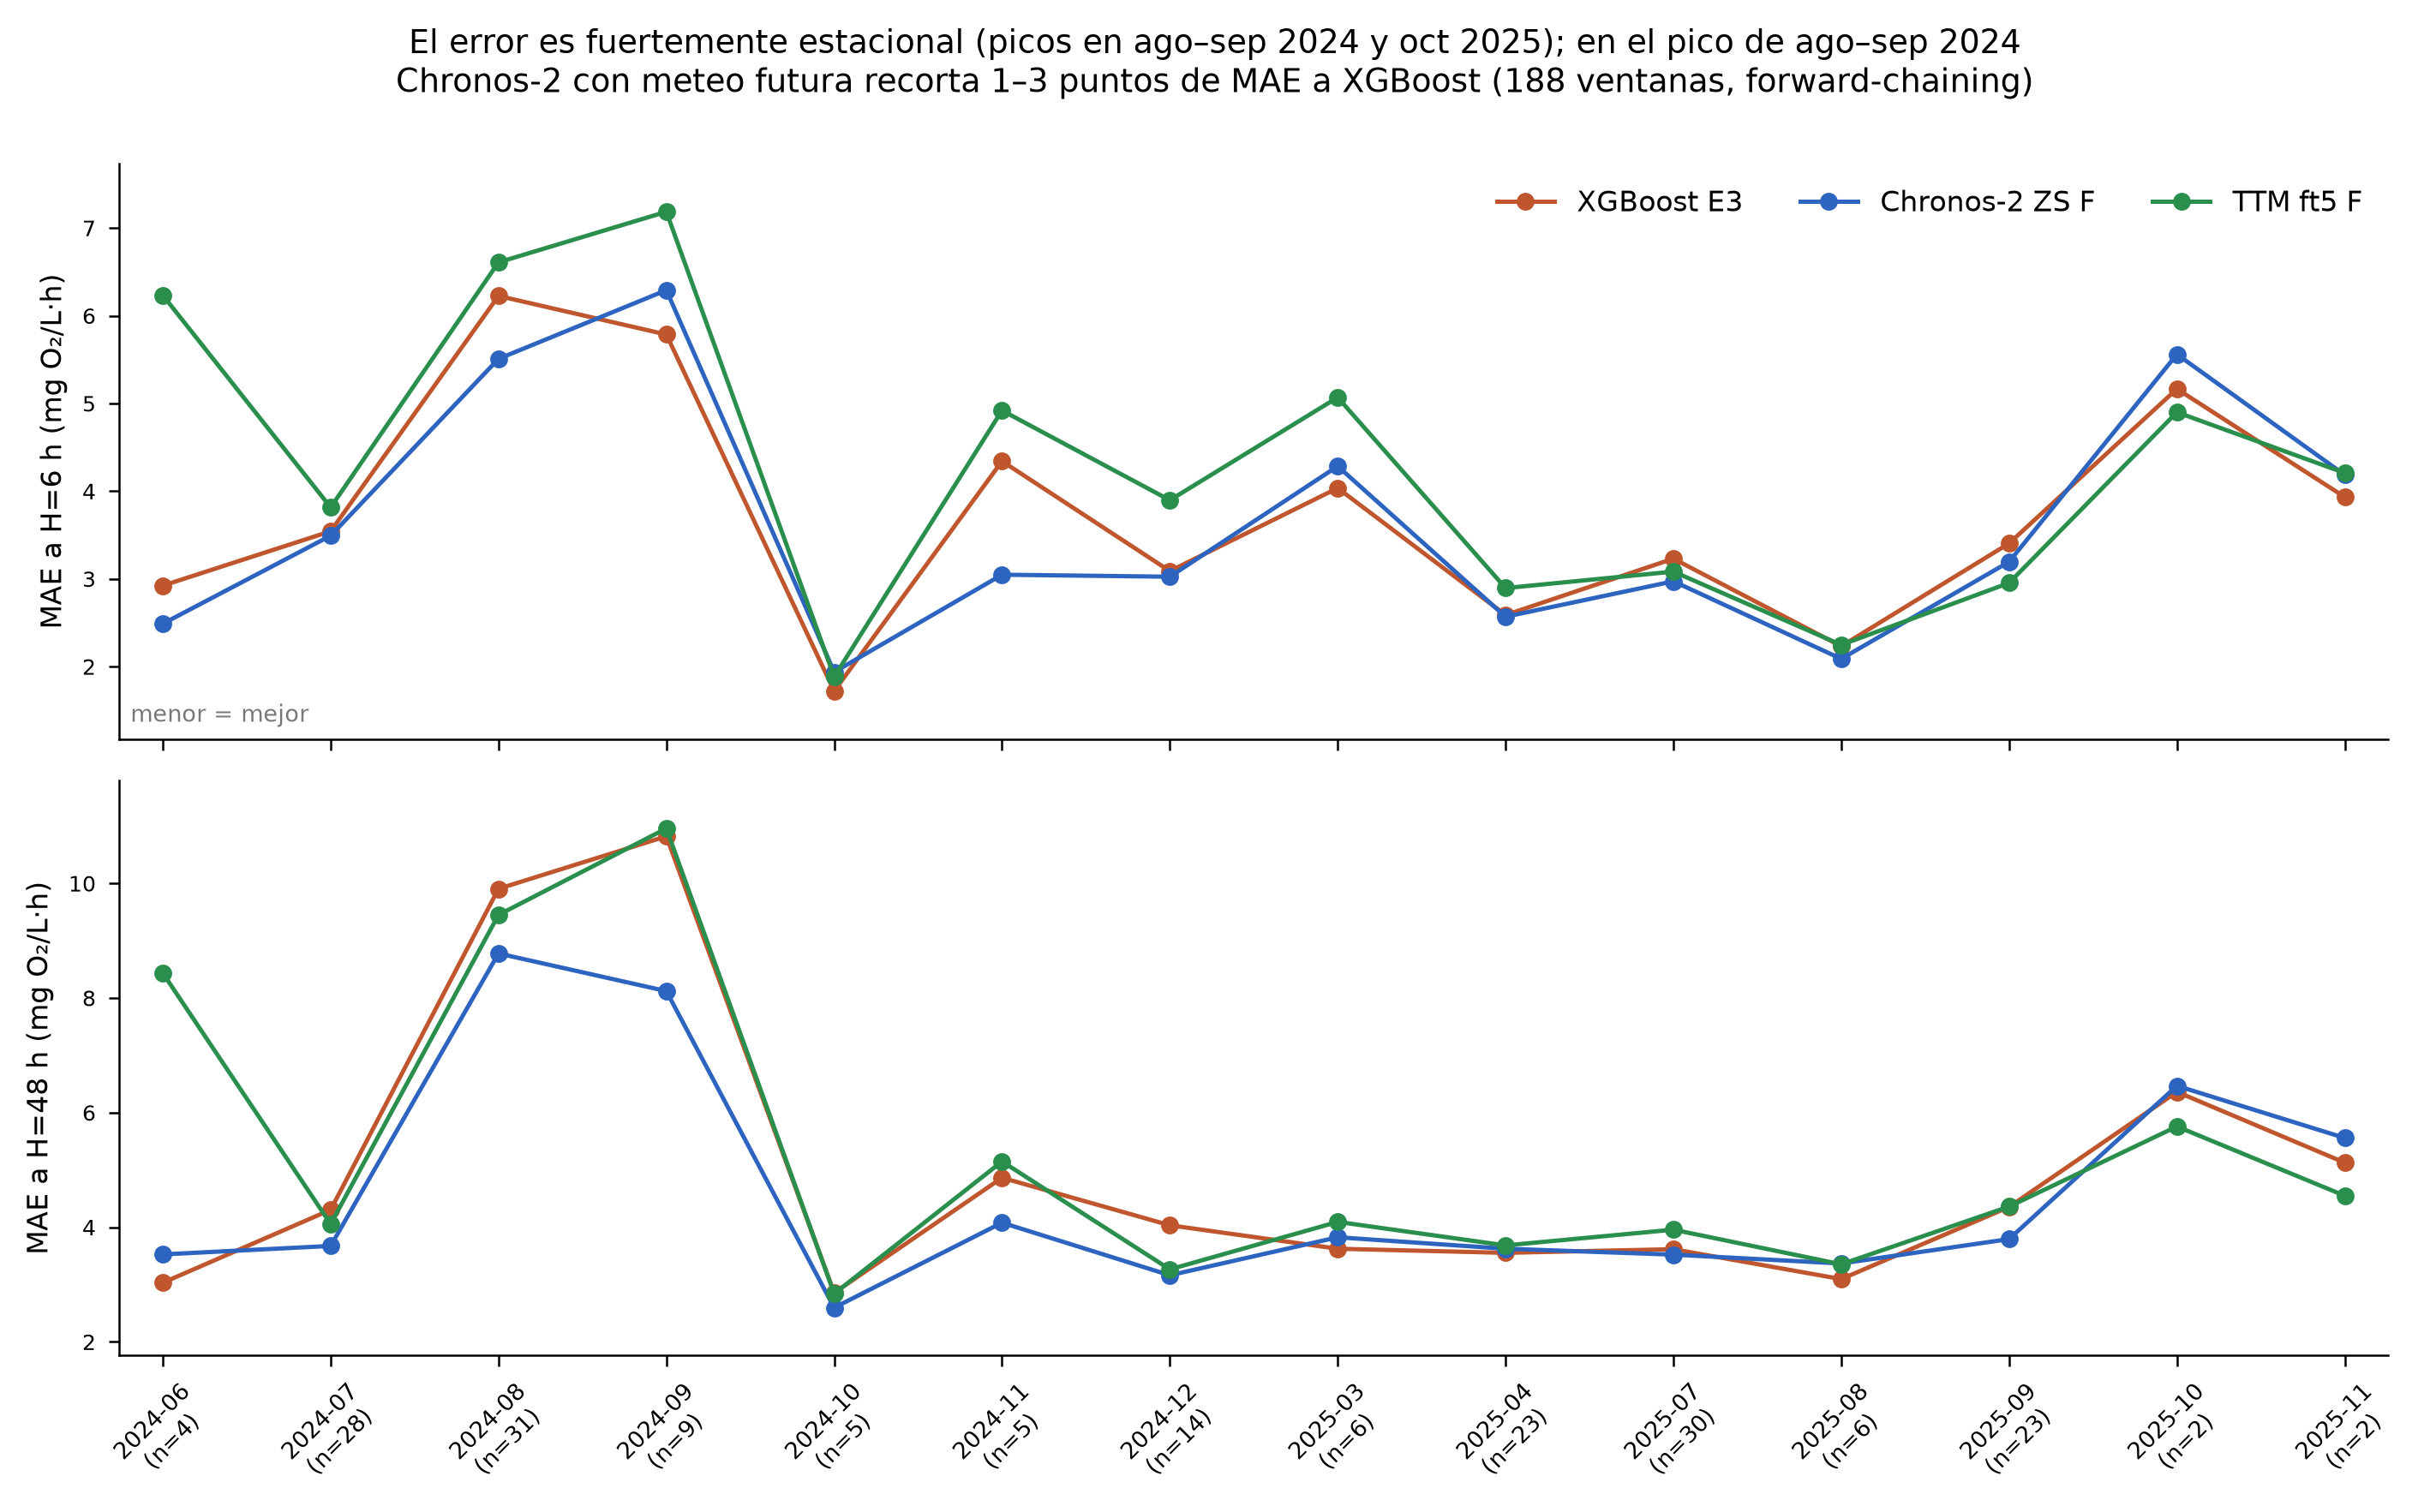

In [4]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
res_b = pd.read_csv("results/validacion_bloques.csv")
FAM = {"xgb_E3": ("XGBoost E3", "#c0562d"), "c2_zs_F_C256": ("Chronos-2 ZS F", "#2d64c0"),
       "ttm_ft5_F": ("TTM ft5 F", "#2a8f4d")}
fig, axes = plt.subplots(2, 1, figsize=(9.5, 5.8), sharex=True)
for ax, H in zip(axes, [6, 48]):
    sub = res_b[res_b.H==H]
    for cfg, (nombre, col) in FAM.items():
        s = sub[sub.config==cfg].set_index("bloque_mes").MAE
        ax.plot(range(len(s)), s.values, "o-", ms=4, color=col, label=nombre if H==6 else None)
    n_v = sub[sub.config=="xgb_E3"].set_index("bloque_mes").n_ventanas
    ax.set_xticks(range(len(n_v)))
    ax.set_xticklabels([f"{m}\n(n={n})" for m, n in n_v.items()], fontsize=6.5, rotation=45)
    ax.set_ylabel(f"MAE a H={H} h (mg O₂/L·h)", fontsize=8)
    ax.margins(x=0.02, y=0.1)
axes[0].legend(frameon=False, fontsize=8, ncols=3, loc="upper right")
axes[0].annotate("menor = mejor", xy=(0.005, 0.03), xycoords="axes fraction", fontsize=6.5, color="#777777")
fig.suptitle("El error es fuertemente estacional (picos en ago–sep 2024 y oct 2025); en el pico de ago–sep 2024\n"
             "Chronos-2 con meteo futura recorta 1–3 puntos de MAE a XGBoost (188 ventanas, forward-chaining)",
             fontsize=9, y=1.00)
fig.tight_layout()
fig.savefig("figures/fig_bloques_estacional.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Conclusión

Ver `resumen_bloques.md`: número total de ventanas y cobertura mensual, qué contrastes alcanzan
significación con la muestra ampliada, si el ranking entre familias cambia por estación, y la
salvedad de que los modelos entrenables usan menos datos en los bloques tempranos.